In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate
import shap
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

In [3]:
claims = pd.read_csv('./cohere_claims.csv').rename(columns=str.lower)
pa = pd.read_csv('./cohere_pa.csv').rename(columns=str.lower)

In [5]:
claims.head()

,pet_name,provider npi,claim id,claim type,amount paid,pet id,claim date
0,Sophie,1008,1551DB6D,Check-up,74.64,PET-1953,2023-03-09 14:26:19
1,Sophie,1008,836C194D,Dental Cleaning,157.98,PET-1953,2023-03-27 14:26:19
2,Sophie,1008,4E38C924,X-ray,354.67,PET-1953,2022-12-23 14:26:19
3,Harper,1006,A4B45594,Check-up,117.51,PET-8260,2023-07-26 14:26:19
4,Harper,1006,16599925,Check-up,50.53,PET-8260,2022-10-01 14:26:19


In [7]:
claims.shape, pa.shape

((788, 7), (2000, 10))

In [9]:
pa.head()

,id,pet_name,service,submission_date,provider_id,unit,authstatus,auto_approved,clinical_reviewer,pet_id
0,14909f64-9eb6-4fc2-b4a7-f67dde5f1f45,Benson,Surgery,2024-06-11 14:26:19,1011,1,Denied,False,Wendy French,PET-1031
1,1dda89cd-0e18-4ca5-9cff-78e644029fdf,Benson,Surgery,2024-01-11 14:26:19,1016,1,Denied,False,NaN,PET-1031
2,21868b05-579e-4b72-8b50-e33a15d3374c,Benson,Vaccination,2023-12-12 14:26:19,1003,4,Approved,True,NaN,PET-1031
3,2da45bff-ed0e-4337-b98a-b2029b07a5a4,Benson,Check-up,2023-09-01 14:26:19,1014,1,Approved,False,NaN,PET-1031
4,67f26d56-e347-47f9-b54d-58a6653c436a,Benson,Vaccination,2024-02-25 14:26:19,1015,1,Pending,False,Efrain Rowland,PET-1031


In [11]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pet_name      788 non-null    object 
 1   provider npi  788 non-null    int64  
 2   claim id      788 non-null    object 
 3   claim type    788 non-null    object 
 4   amount paid   788 non-null    float64
 5   pet id        788 non-null    object 
 6   claim date    788 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 43.2+ KB


In [13]:
pa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   object
 1   pet_name           2000 non-null   object
 2   service            2000 non-null   object
 3   submission_date    2000 non-null   object
 4   provider_id        2000 non-null   int64 
 5   unit               2000 non-null   int64 
 6   authstatus         2000 non-null   object
 7   auto_approved      2000 non-null   bool  
 8   clinical_reviewer  612 non-null    object
 9   pet_id             2000 non-null   object
dtypes: bool(1), int64(2), object(7)
memory usage: 142.7+ KB


## normalize columns and standardize column names

In [16]:
pa.columns = pa.columns.astype(str).str.strip().str.lower()
claims.columns = claims.columns.astype(str).str.strip().str.lower()

In [18]:
claims = claims.rename(columns={
    "pet name": "pet_name",
    "pet id": "pet_id",
    "provider npi": "provider_npi",
    "claim id": "claim_id",
    "claim type": "claim_type",
    "amount paid": "amount_paid",
    "claim date": "claim_date"
})

In [20]:
claims.head()

,pet_name,provider_npi,claim_id,claim_type,amount_paid,pet_id,claim_date
0,Sophie,1008,1551DB6D,Check-up,74.64,PET-1953,2023-03-09 14:26:19
1,Sophie,1008,836C194D,Dental Cleaning,157.98,PET-1953,2023-03-27 14:26:19
2,Sophie,1008,4E38C924,X-ray,354.67,PET-1953,2022-12-23 14:26:19
3,Harper,1006,A4B45594,Check-up,117.51,PET-8260,2023-07-26 14:26:19
4,Harper,1006,16599925,Check-up,50.53,PET-8260,2022-10-01 14:26:19


#### Datetime parsing (timezones): submission_date and claim_date are loaded as object strings, so I convert them to pandas datetime64[ns] to enable point-in-time filtering (e.g., claim_date < submission_date). The timestamps in this dataset are timezone-naive (no UTC offsets like Z/+00:00), so I keep them as naive datetimes and apply comparisons consistently. If timezone-aware timestamps were present, I would standardize to UTC before feature engineering.

In [23]:
# 1) ensure datetime + no nulls in merge keys
pa["submission_date"] = pd.to_datetime(pa["submission_date"], errors="coerce")
claims["claim_date"] = pd.to_datetime(claims["claim_date"], errors="coerce")

pa = pa.dropna(subset=["pet_id", "submission_date"]).copy()
claims = claims.dropna(subset=["pet_id", "claim_date"]).copy()

In [25]:
pa.shape, claims.shape

((2000, 10), (788, 7))

### Feature Engineering: Severity mapping for Claims
We convert raw claim history into an interpretable clinical utilization / intensity signal. Each claim type is assigned a severity weight to reflect relative clinical intensity (and typical downstream cost/complexity). 
Examples (10): high complexity and high cost potential. 
X-ray / Imaging (5): moderate clinical intensity.
Lab Test (5): moderate clinical intensity. 
Dental Cleaning (3): low–moderate intensity
Check-up / Vaccination (1): routine / low intensity. 
We then combine the weight with the paid amount using a diminishing-returns transform = weight(claim_type) × log1p(amount_paid).
Why log1p? Claim payments are typically right-skewed (a few very large values). log1p preserves ordering while reducing the impact of extreme outliers, producing a more stable feature for modeling.Note: This weighting scheme is a heuristic to encode domain knowledge; it is not a clinical guideline. In a production setting, these weights could be refined using clinician input and/or learned from data.

In [28]:
claims.claim_type.unique()

array(['Check-up', 'Dental Cleaning', 'X-ray', 'Vaccination', 'Lab Test',
       'Surgery'], dtype=object)

In [30]:
severity_map = {
    "surgery": 10,
    "x-ray": 5,    
    "lab test": 5,
    "dental cleaning": 3,
    "check-up": 1,
    "vaccination": 1,
}

claims["claim_type_norm"] = claims["claim_type"].astype(str).str.strip().str.lower()
claims["w"] = claims["claim_type_norm"].map(severity_map).fillna(1)
claims["amount_paid"] = pd.to_numeric(claims["amount_paid"], errors="coerce").fillna(0)
claims["paid_severity"] = claims["w"] * np.log1p(claims["amount_paid"])

In [32]:
claims.head()

,pet_name,provider_npi,claim_id,claim_type,amount_paid,pet_id,claim_date,claim_type_norm,w,paid_severity
0,Sophie,1008,1551DB6D,Check-up,74.64,PET-1953,2023-03-09 14:26:19,check-up,1,4.325985
1,Sophie,1008,836C194D,Dental Cleaning,157.98,PET-1953,2023-03-27 14:26:19,dental cleaning,3,15.206335
2,Sophie,1008,4E38C924,X-ray,354.67,PET-1953,2022-12-23 14:26:19,x-ray,5,29.370017
3,Harper,1006,A4B45594,Check-up,117.51,PET-8260,2023-07-26 14:26:19,check-up,1,4.774997
4,Harper,1006,16599925,Check-up,50.53,PET-8260,2022-10-01 14:26:19,check-up,1,3.942164


### Feature Engineering: point-in_time features and cumulative total claims in the last 90 days and 365 days

In [35]:
def build_pa_features_simple(pa, claims, windows=(90, 365)):
    pa = pa.copy()
    cl = claims.copy()

    # ensure datetime
    pa["submission_date"] = pd.to_datetime(pa["submission_date"], errors="coerce")
    cl["claim_date"] = pd.to_datetime(cl["claim_date"], errors="coerce")

    pa = pa.dropna(subset=["id","pet_id","submission_date"])
    cl = cl.dropna(subset=["pet_id","claim_date"])

    claims_by_pet = {k: g.sort_values("claim_date") for k, g in cl.groupby("pet_id")}

    rows = []
    for _, r in pa.iterrows():
        pet = r["pet_id"]
        t = r["submission_date"]

        hist = claims_by_pet.get(pet)
        if hist is None:
            # cold start
            feat = {"id": r["id"], "has_history": 0, "days_since_last_claim": 999,
                    "hist_claim_count": 0, "hist_total_spent": 0, "hist_total_severity": 0}
            for w in windows:
                feat[f"claim_count_{w}d"] = 0
                feat[f"spent_{w}d"] = 0
                feat[f"severity_{w}d"] = 0
            rows.append(feat)
            continue

        # only claims strictly before submission
        h = hist[hist["claim_date"] < t]

        if h.empty:
            feat = {"id": r["id"], "has_history": 0, "days_since_last_claim": 999,
                    "hist_claim_count": 0, "hist_total_spent": 0, "hist_total_severity": 0}
            for w in windows:
                feat[f"claim_count_{w}d"] = 0
                feat[f"spent_{w}d"] = 0
                feat[f"severity_{w}d"] = 0
            rows.append(feat)
            continue

        feat = {
            "id": r["id"],
            "has_history": 1,
            "days_since_last_claim": int((t - h["claim_date"].max()).days),
            "hist_claim_count": int(len(h)),
            "hist_total_spent": float(h["amount_paid"].sum()),
            "hist_total_severity": float(h["paid_severity"].sum()),
        }

        for w in windows:
            cutoff = t - pd.Timedelta(days=w)
            hw = h[h["claim_date"] >= cutoff]
            feat[f"claim_count_{w}d"] = int(len(hw))
            feat[f"spent_{w}d"] = float(hw["amount_paid"].sum())
            feat[f"severity_{w}d"] = float(hw["paid_severity"].sum())

        rows.append(feat)

    return pd.DataFrame(rows)

In [37]:
pa_feats = build_pa_features_simple(pa, claims, windows=(90, 365))
final_df = pa.merge(pa_feats, on="id", how="left")

In [39]:
final_df.columns

Index(['id', 'pet_name', 'service', 'submission_date', 'provider_id', 'unit',
       'authstatus', 'auto_approved', 'clinical_reviewer', 'pet_id',
       'has_history', 'days_since_last_claim', 'hist_claim_count',
       'hist_total_spent', 'hist_total_severity', 'claim_count_90d',
       'spent_90d', 'severity_90d', 'claim_count_365d', 'spent_365d',
       'severity_365d'],
      dtype='object')

In [41]:
final_df["days_since_last_claim"].isna().sum()

0

In [43]:
final_df["unit"].isna().sum()

0

In [114]:
final_df[final_df['pet_name'] == 'Jake']

,id,pet_name,service,submission_date,provider_id,unit,authstatus,auto_approved,clinical_reviewer,pet_id,...,days_since_last_claim,hist_claim_count,hist_total_spent,hist_total_severity,claim_count_90d,spent_90d,severity_90d,claim_count_365d,spent_365d,severity_365d
1940,00782d5e-0960-400c-9fae-1c4cb16bd091,Jake,Lab Test,2024-06-12 14:26:19,1020,3,Approved,True,NaN,PET-9578,...,554,3,3329.38,101.17297,0,0.0,0.0,0,0.00,0.000000
1941,164ca36a-a77d-4a8d-9523-42d6c125e6d5,Jake,Surgery,2023-10-31 14:26:19,1009,1,Denied,False,NaN,PET-9578,...,329,3,3329.38,101.17297,0,0.0,0.0,1,61.04,4.127779
1942,22bb8268-da94-4bf1-af63-933a09f2a5bd,Jake,X-ray,2024-06-01 14:26:19,1003,3,Pending,False,NaN,PET-9578,...,543,3,3329.38,101.17297,0,0.0,0.0,0,0.00,0.000000
1943,44e27f4d-edb8-44c2-b56e-00ee18184fd4,Jake,X-ray,2024-08-07 14:26:19,1012,1,Denied,False,NaN,PET-9578,...,610,3,3329.38,101.17297,0,0.0,0.0,0,0.00,0.000000
1944,695a628f-4516-4701-aa1f-45ce7b807436,Jake,Check-up,2024-06-21 14:26:19,1020,1,Approved,False,Malachi Clements,PET-9578,...,563,3,3329.38,101.17297,0,0.0,0.0,0,0.00,0.000000
1945,8d23dcc3-0e55-4365-929e-23b70f9c2bb3,Jake,Vaccination,2023-12-01 14:26:19,1016,4,Denied,False,NaN,PET-9578,...,360,3,3329.38,101.17297,0,0.0,0.0,1,61.04,4.127779
1946,8f14d315-e625-4929-8636-7d046aaa8467,Jake,Check-up,2024-05-07 14:26:19,1008,1,Approved,True,Karen Wallace,PET-9578,...,518,3,3329.38,101.17297,0,0.0,0.0,0,0.00,0.000000
1947,9d4b1e95-41cd-406d-b32c-f20f4dddb1c1,Jake,X-ray,2023-09-09 14:26:19,1017,3,Approved,False,NaN,PET-9578,...,277,3,3329.38,101.17297,0,0.0,0.0,1,61.04,4.127779
1948,9e4b2f9b-5dfc-4002-b02c-40f9ce683266,Jake,Vaccination,2023-08-23 14:26:19,1002,2,Approved,False,Sarai Ramos,PET-9578,...,260,3,3329.38,101.17297,0,0.0,0.0,1,61.04,4.127779


## spot-check leakage: pick 5 PAs, ensure no claim is included after submission

In [45]:
sample_ids = final_df["id"].dropna().sample(5, random_state=0).tolist()
for pid in sample_ids:
    t = final_df.loc[final_df["id"] == pid, "submission_date"].iloc[0]
    pet = final_df.loc[final_df["id"] == pid, "pet_id"].iloc[0]
    h = claims[(claims["pet_id"] == pet) & (claims["claim_date"] < t)]
    assert (h["claim_date"] < t).all()
print("Leakage check passed on sample.")

Leakage check passed on sample.


### Data Pipeline: Remove Pending status from Auth Status.

In [47]:
# 1) labels + split
df = final_df[final_df["authstatus"] != "Pending"].copy()
df["y_denied"] = (df["authstatus"] == "Denied").astype(int)

### Train Test Split: Train 2023 PA data and validate 2024 data

In [49]:
train = df[df["submission_date"].dt.year == 2023].copy()
test  = df[df["submission_date"].dt.year == 2024].copy()

num_history = [
    "hist_claim_count","hist_total_severity","claim_count_90d","severity_90d",
    "claim_count_365d","severity_365d"
]
num_other = ['unit', 'days_since_last_claim']  

features_cat = ["service"]

features_bin = ["has_history"]

y_train = train["y_denied"]
y_test  = test["y_denied"]
X_train = train[num_history + num_other + features_bin + features_cat]
X_test  = test[num_history + num_other + features_bin + features_cat]

# normalize the numerical features: important for LASSO
prep = ColumnTransformer([
    ("hist_num", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler())
    ]), num_history + features_bin),

    ("other_num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_other),

    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ]), features_cat),
], remainder="drop")

In [51]:
X_train_prep = prep.fit_transform(X_train, y_train)
X_test_prep  = prep.transform(X_test)

### LASSO Regression with Cross Validation for Feature Selection

In [53]:
lasso_cv = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    Cs=[0.05, 0.1, 0.2, 0.5, 1.0],  # small + fast
    cv=5,
    scoring="average_precision",
    class_weight="balanced",
    max_iter=8000,
    n_jobs=-1,
    refit=True,
    random_state=42
)

lasso_cv.fit(X_train_prep, y_train)

best_C = float(lasso_cv.C_[0])
print("Best C:", best_C)


selector = SelectFromModel(lasso_cv, threshold=1e-8, prefit= False)

X_train_sel = selector.transform(X_train_prep)
X_test_sel  = selector.transform(X_test_prep)

print("Prep shape:", X_train_prep.shape, "-> Selected shape:", X_train_sel.shape)

Best C: 0.2
Prep shape: (698, 15) -> Selected shape: (698, 11)


### Selected Features from LASSO Regression

In [55]:
feature_names = prep.get_feature_names_out()
mask = selector.get_support()
selected_names = feature_names[mask]
print("Selected features:", len(selected_names))
print(selected_names)

Selected features: 11
['hist_num__hist_claim_count' 'hist_num__claim_count_365d'
 'hist_num__has_history' 'other_num__unit'
 'other_num__days_since_last_claim' 'cat__service_Check-up'
 'cat__service_Dental Cleaning' 'cat__service_Lab Test'
 'cat__service_Surgery' 'cat__service_Vaccination' 'cat__service_X-ray']


### XGBoost: Apply Selected Features from LASSO to XGBoost for training

In [57]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1
)

xgb_pipe = Pipeline([
    ("prep", prep),
    ("select", selector),
    ("model", xgb),
])

xgb_pipe.fit(X_train, y_train)

p_denied = xgb_pipe.predict_proba(X_test)[:, 1]
yhat_denied = xgb_pipe.predict(X_test)

### Evaluation Metrics Using 2024 PA Validation

In [59]:
p_denied = xgb_pipe.predict_proba(X_test)[:, 1]
p_approved = 1 - p_denied
yhat_denied = xgb_pipe.predict(X_test)

print("2024 ROC-AUC:", roc_auc_score(y_test, p_denied))
print("2024 PR-AUC :", average_precision_score(y_test, p_denied))
print("Confusion matrix:\n", confusion_matrix(y_test, yhat_denied))
print(classification_report(y_test, yhat_denied, target_names=["Approved(0)", "Denied(1)"]))

2024 ROC-AUC: 0.8195833664099919
2024 PR-AUC : 0.5698902716360722
Confusion matrix:
 [[682 202]
 [ 97 245]]
              precision    recall  f1-score   support

 Approved(0)       0.88      0.77      0.82       884
   Denied(1)       0.55      0.72      0.62       342

    accuracy                           0.76      1226
   macro avg       0.71      0.74      0.72      1226
weighted avg       0.78      0.76      0.76      1226



### ROC Curve

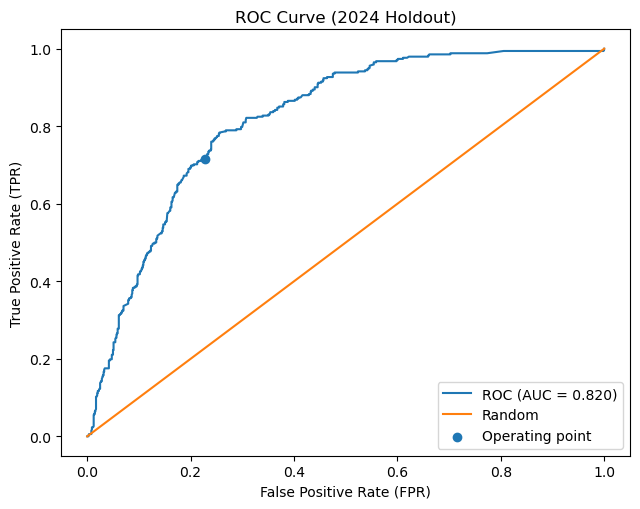

In [61]:
fpr, tpr, roc_thresholds = roc_curve(y_test, p_denied)
roc_auc = roc_auc_score(y_test, p_denied)

TN, FP, FN, TP = confusion_matrix(y_test, yhat_denied).ravel()
fpr_point = FP / (FP + TN)
tpr_point = TP / (TP + FN)

plt.figure(figsize=(6.5, 5.2))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], label="Random")
plt.scatter([fpr_point], [tpr_point], label="Operating point")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (2024 Holdout)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_2024.png", dpi=300)
plt.savefig("roc_curve_2024.pdf")  # nice for slides
plt.show()

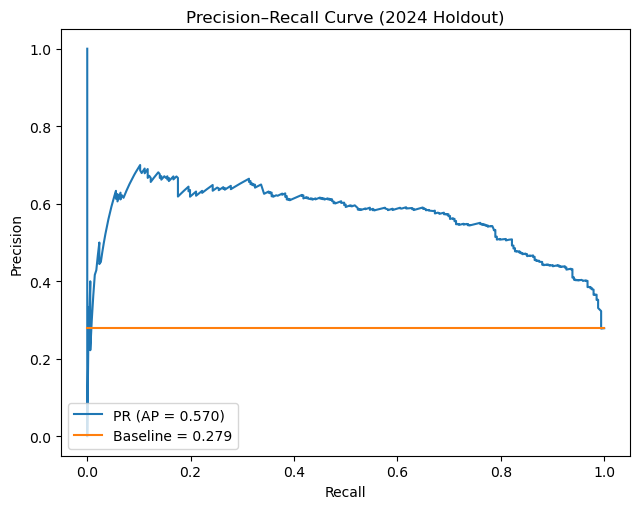

In [63]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, p_denied)
pr_auc = average_precision_score(y_test, p_denied)
baseline = np.mean(y_test)  # prevalence of Denied

plt.figure(figsize=(6.5, 5.2))
plt.plot(recall, precision, label=f"PR (AP = {pr_auc:.3f})")
plt.plot([0, 1], [baseline, baseline], label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (2024 Holdout)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("pr_curve_2024.png", dpi=300)
plt.savefig("pr_curve_2024.pdf")
plt.show()

### A threshold tradeoff table (coverage vs safety)
The Result: At 0.98, we likely capture about 20-30% of the volume for auto-approval while maintaining near-perfect precision.

In [65]:
thresholds = [0.95, 0.97, 0.98, 0.984, 0.99, 0.995]

rows = []
for thr in thresholds:
    auto = (p_approved >= thr)
    n_auto = int(auto.sum())
    coverage = float(auto.mean())
    if n_auto > 0:
        precision_auto = float((y_test[auto] == 0).mean())    # Approved among auto-approved
        false_approve_rate = float((y_test[auto] == 1).mean())
        false_approvals = int((y_test[auto] == 1).sum())
        true_approvals = int((y_test[auto] == 0).sum())
    else:
        precision_auto = np.nan
        false_approve_rate = np.nan
        false_approvals = 0
        true_approvals = 0

    rows.append([thr, coverage, n_auto, precision_auto, false_approve_rate, true_approvals, false_approvals])

tradeoff = pd.DataFrame(
    rows,
    columns=["approval_threshold", "coverage", "n_auto", "precision_auto", "false_approve_rate", "true_approvals", "false_approvals"]
)

tradeoff

,approval_threshold,coverage,n_auto,precision_auto,false_approve_rate,true_approvals,false_approvals
0,0.950,0.296900,364,0.972527,0.027473,354,10
1,0.970,0.265090,325,0.978462,0.021538,318,7
2,0.980,0.238173,292,0.982877,0.017123,287,5
3,0.984,0.233279,286,0.982517,0.017483,281,5
4,0.990,0.209625,257,0.984436,0.015564,253,4
5,0.995,0.127243,156,0.987179,0.012821,154,2


### Cross Validation: 5-fold stratified CV performed on 2023 only; 2024 held out for final evaluation.

In [67]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

cv_res = cross_validate(
    xgb_pipe,                
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    k: [np.mean(v), np.std(v)]
    for k, v in cv_res.items()
    if k.startswith("test_")
}, index=["mean", "std"]).T

cv_summary

,mean,std
test_roc_auc,0.825807,0.033592
test_pr_auc,0.601692,0.046431
test_f1,0.593411,0.056072
test_precision,0.505429,0.068134
test_recall,0.730583,0.083112


### SHAP & Intepretation: SHAP computed on the final trained model to explain drivers of predicted denial risk.

In [70]:
# Fit on full 2023 (already done, but safe to re-run once here)
xgb_pipe.fit(X_train, y_train)

prep_step = xgb_pipe.named_steps["prep"]
sel_step  = xgb_pipe.named_steps["select"]
xgb_model = xgb_pipe.named_steps["model"]

# Transform 2024 into the exact feature space XGBoost sees
X_test_prep = prep_step.transform(X_test)
X_test_sel  = sel_step.transform(X_test_prep)

# Get feature names after one-hot + selection
all_names = prep_step.get_feature_names_out()
mask = sel_step.get_support()
selected_names = all_names[mask]

# SHAP needs dense sometimes; this is a safe conversion for your dataset size
X_shap = X_test_sel.toarray() if hasattr(X_test_sel, "toarray") else X_test_sel

#### SHAP: Global Importance (beeswarm)

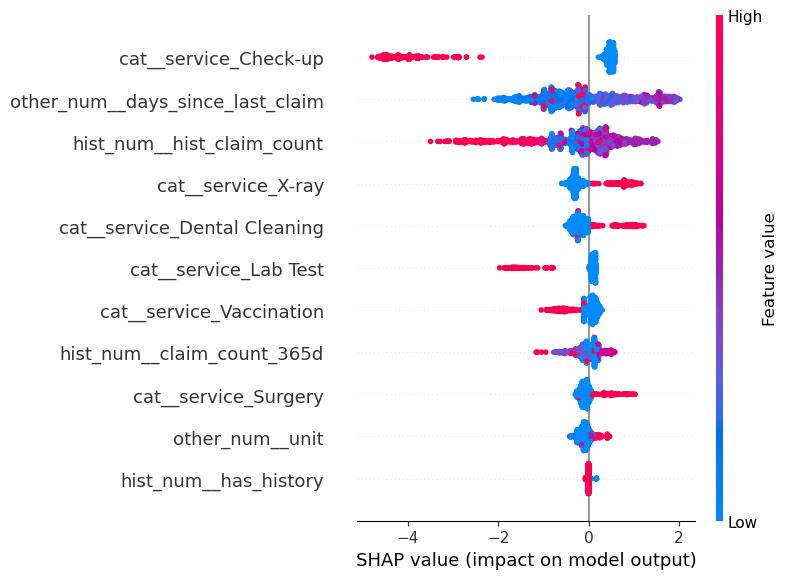

In [73]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, feature_names=selected_names, max_display=20)

#### SHAP: Global Importance (bar)

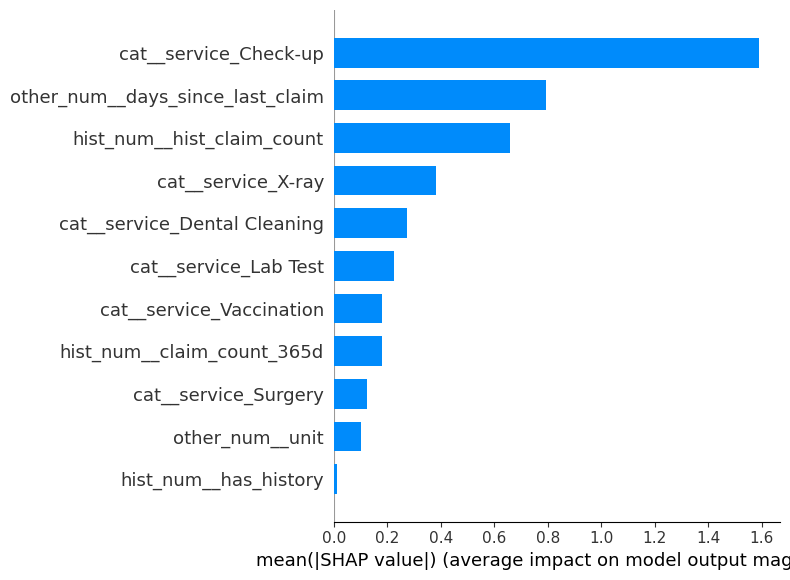

In [75]:
shap.summary_plot(shap_values, X_shap, feature_names=selected_names, plot_type="bar", max_display=20)

In [110]:
X_train.shape

(698, 10)